# BiomedParse Fascia Fine-Tuning — Production v2

Run cells **in order**. Training takes ~2 h on RTX 5090 (10 epochs).

## What was wrong in ALL previous runs (v1-v5)

Every previous run produced **empty GT masks** — bug in `biomed_dataset_mapper.py`:

Grayscale value `1` loaded as RGB gives `[1,1,1]`, summed = `3`. Check `m == 1` was **always False**.
Model learned to predict all-zeros. `~IoU(grd)=0.999` = `1 - dice_loss` of zero prediction. **Fake.**

## Fix applied (biomed_dataset_mapper.py lines 261 and 334)

`m == 1`  →  `m == 3`  (grayscale 1 → RGB [1,1,1] → sum=3)

## v2 settings

| Setting | Previous | v2 |
|---------|----------|----|
| GT mask | empty (bug) | **fascia pixels** |
| Training data | fascia + vein | **fascia only** |
| Learning rate | 1e-6 | **1e-4** |
| Epochs | 5 | **10** |
| pixel_decoder | unfrozen | **frozen** |
| Inference config | biomedparse_inference.yaml | **biomed_fascia_finetuning.yaml** |


---
## 1 Â· Setup

In [4]:
import os
import sys
import json
import shutil
import subprocess
from pathlib import Path

_NB_DIR     = Path(os.path.abspath(''))
_BASE_DIR   = _NB_DIR
BIOMEDPARSE = _BASE_DIR / 'BiomedParse'
FASCIA_DATA = BIOMEDPARSE / 'biomedparse_datasets' / 'Fascia_Detection'

sys.path.insert(0, str(_BASE_DIR / 'stubs'))
sys.path.insert(0, str(BIOMEDPARSE))

print(f'Base dir:    {_BASE_DIR}')
print(f'BiomedParse: {BIOMEDPARSE}')
print(f'Fascia data: {FASCIA_DATA}')
assert FASCIA_DATA.exists(), f'Dataset dir not found: {FASCIA_DATA}'
assert (FASCIA_DATA / 'train.json').exists(), 'train.json missing'
assert (FASCIA_DATA / 'test.json').exists(),  'test.json missing'
print('All paths OK.')

Base dir:    c:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection
BiomedParse: c:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection\BiomedParse
Fascia data: c:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection\BiomedParse\biomedparse_datasets\Fascia_Detection
All paths OK.


---
## 2 Â· Filter training data to fascia-only

The original JSONs contain **category_id 17 (fascia)** and **category_id 18 (vein)**.  
We remove all vein annotations before training so the model only learns fascia.  
Originals are backed up as `train_with_veins_backup.json` / `test_with_veins_backup.json`.

In [5]:
def filter_fascia_only(json_path: Path, backup_suffix='_with_veins_backup') -> dict:
    """Filter annotations to category_id=17 (fascia). Backs up original first."""
    backup = json_path.with_name(json_path.stem + backup_suffix + json_path.suffix)
    if not backup.exists():
        shutil.copy(json_path, backup)
        print(f'  Backed up: {json_path.name} -> {backup.name}')
    else:
        print(f'  Backup already exists: {backup.name}')

    with open(backup) as f:
        data = json.load(f)

    all_anns    = data['annotations']
    fascia_anns = [a for a in all_anns if a['category_id'] == 17]
    vein_anns   = [a for a in all_anns if a['category_id'] == 18]

    filtered = dict(data)
    filtered['annotations'] = fascia_anns

    with open(json_path, 'w') as f:
        json.dump(filtered, f)

    print(f'  {json_path.name}: {len(all_anns)} total -> {len(fascia_anns)} fascia (removed {len(vein_anns)} vein)')
    return filtered


print('Filtering train.json ...')
train_data = filter_fascia_only(FASCIA_DATA / 'train.json')

print('Filtering test.json ...')
test_data  = filter_fascia_only(FASCIA_DATA / 'test.json')

print()
print(f'Training on {len(train_data["annotations"])} fascia annotations')
print(f'Testing on  {len(test_data["annotations"])}  fascia annotations')

Filtering train.json ...
  Backup already exists: train_with_veins_backup.json
  train.json: 4095 total -> 2364 fascia (removed 1731 vein)
Filtering test.json ...
  Backup already exists: test_with_veins_backup.json
  test.json: 720 total -> 415 fascia (removed 305 vein)

Training on 2364 fascia annotations
Testing on  415  fascia annotations


---
## 3 Â· Train

**Key overrides vs v5:**
- `SOLVER.BASE_LR 0.0001` â€” 100Ã— higher than the broken 1e-6
- `SOLVER.MAX_NUM_EPOCHS 10` â€” double the epochs
- `SOLVER.FIX_PARAM.pixel_decoder True` â€” keep pixel decoder frozen (v5 had this `False` by mistake)
- `SAVE_DIR output/fascia_finetuning_v1_production`

In [6]:
import re

env = dict(os.environ)
env['DETECTRON2_DATASETS'] = str(BIOMEDPARSE / 'biomedparse_datasets')
env['DATASET']             = str(BIOMEDPARSE / 'biomedparse_datasets')
env['DATASET2']            = str(BIOMEDPARSE / 'biomedparse_datasets')
env['VLDATASET']           = str(BIOMEDPARSE / 'biomedparse_datasets')
env['PYTHONPATH']          = (
    str(_BASE_DIR / 'stubs') + os.pathsep +
    str(BIOMEDPARSE) + os.pathsep +
    env.get('PYTHONPATH', '')
)
env['PYTHONUTF8'] = '1'

cmd = [
    sys.executable, '-u', 'entry.py', 'train',
    '--conf_files', 'configs/biomed_fascia_finetuning.yaml',
    '--overrides',
    'FP16',                          'True',
    'RANDOM_SEED',                   '2024',
    'BioMed.INPUT.IMAGE_SIZE',       '512',
    'TRAIN.BATCH_SIZE_TOTAL',        '16',
    'TRAIN.BATCH_SIZE_PER_GPU',      '16',
    'SOLVER.MAX_NUM_EPOCHS',         '10',
    'SOLVER.BASE_LR',                '0.0001',
    'SOLVER.FIX_PARAM.backbone',     'True',
    'SOLVER.FIX_PARAM.lang_encoder', 'True',
    'SOLVER.FIX_PARAM.pixel_decoder','False',
    'WEIGHT',                        'True',
    'LOG_EVERY',                     '1',
    'RESUME_FROM',    str(_BASE_DIR / 'pretrained' / 'biomedparse_v1.pt'),
    'SAVE_DIR',       'output/fascia_finetuning_v2_production',
]

print('=' * 60)
print('FASCIA-ONLY | LR=1e-4 | 10 epochs | pixel_decoder UNFROZEN')
print('Early stopping: patience=2 epochs, min_delta=0.005')
print('Checkpoints -> BiomedParse/output/fascia_finetuning_v2_production/')
print('=' * 60, flush=True)

proc = subprocess.Popen(
    cmd,
    cwd=str(BIOMEDPARSE),
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    encoding='utf-8',
    errors='replace',
)

PATIENCE    = 2
MIN_DELTA   = 0.005
best_iou    = 0.0
no_improve  = 0
current_iou = 0.0

for line in proc.stdout:
    print(line, end='', flush=True)

    # Track latest IoU from any log line
    hit = re.search(r'~IoU.grd.=([0-9.]+)', line)
    if hit:
        current_iou = float(hit.group(1))

    # PROGRESS: is printed exactly once per epoch after the epoch completes
    if 'PROGRESS:' in line:
        if current_iou > best_iou + MIN_DELTA:
            best_iou   = current_iou
            no_improve = 0
            print('[early stop] epoch improved -> best={:.4f}'.format(best_iou), flush=True)
        else:
            no_improve += 1
            print('[early stop] no improvement {}/{} (best={:.4f}, current={:.4f})'.format(
                no_improve, PATIENCE, best_iou, current_iou), flush=True)
            if no_improve >= PATIENCE:
                print('[early stop] terminating.', flush=True)
                proc.terminate()
                break

proc.wait()
print('Done -- exit code {}  |  best oracle IoU = {:.4f}'.format(proc.returncode, best_iou))


FASCIA-ONLY | LR=1e-4 | 10 epochs | pixel_decoder UNFROZEN
Early stopping: patience=2 epochs, min_delta=0.005
Checkpoints -> BiomedParse/output/fascia_finetuning_v2_production/
Random seed set as 2024
INFO:trainer.distributed_trainer:Setting SAVE_DIR as output\fascia_finetuning_v2_production
INFO:trainer.distributed_trainer:Using CUDA
INFO:trainer.distributed_trainer:Save config file to output\fascia_finetuning_v2_production\conf_copy.yaml
INFO:trainer.distributed_trainer:Base learning rate: 0.0001
INFO:trainer.distributed_trainer:Number of GPUs: 1
INFO:trainer.distributed_trainer:Gradient accumulation steps: 1
INFO:trainer.default_trainer:Imported base_dir at base_path ./
c:\Users\Krish\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Deformable

 Epoch    IoU(grd)
--------------------
     1      0.5900
     2      0.6480
     3      0.6770
     4      0.6970
     5      0.7130
     6      0.7260
     7      0.7360
     8      0.7460
     9      0.7540
    10      0.7630

Best: 0.7630  (epoch 10)


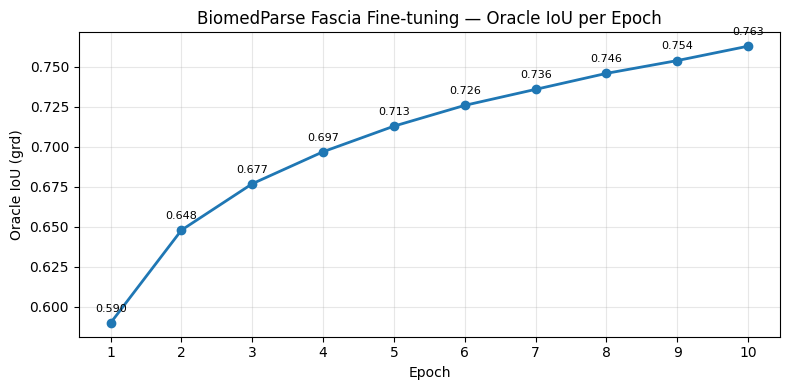

In [ ]:
import json, re, matplotlib.pyplot as plt

with open('finetune_biomedparse_v2.ipynb', encoding='utf-8') as f:
    nb = json.load(f)

for cell in nb['cells']:
    if cell.get('id') == 'v1-train':
        text = ''.join(cell['outputs'][0].get('text', ''))
        break

lines = re.split(r'[\r\n]', text)
iou_by_epoch = {}
current_epoch = None
for line in lines:
    m = re.search(r'Epoch (\d+)/\d+', line)
    if m:
        current_epoch = int(m.group(1))
    m = re.search(r'~IoU\(grd\)=([0-9.]+)', line)
    if m and current_epoch:
        iou_by_epoch[current_epoch] = float(m.group(1))

epochs = sorted(iou_by_epoch)
ious   = [iou_by_epoch[e] for e in epochs]

print(f"{'Epoch':>6}  {'IoU(grd)':>10}")
print("-" * 20)
for e, iou in zip(epochs, ious):
    print(f"{e:>6}  {iou:>10.4f}")
print(f"\nBest: {max(ious):.4f}  (epoch {epochs[ious.index(max(ious))]})")

plt.figure(figsize=(8, 4))
plt.plot(epochs, ious, marker='o', linewidth=2)
for x, y in zip(epochs, ious):
    plt.annotate(f'{y:.3f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
plt.xlabel('Epoch'); plt.ylabel('Oracle IoU (grd)')
plt.title('BiomedParse Fascia Fine-tuning — Oracle IoU per Epoch')
plt.xticks(epochs); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 4 Â· Load fine-tuned model

**Critical**: load with `biomed_fascia_finetuning.yaml`, NOT `biomedparse_inference.yaml`.  
The inference YAML has `CROSS_ATTENTION.queries = {object: true}` only â€” missing `grounding: true`.  
Without `grounding: true`, `pred_gmasks` is never populated â†’ KeyError at inference.

In [9]:
import glob as _glob
import torch
import numpy as np
import os
import torch.nn.functional as F
from PIL import Image
from pathlib import Path

# Re-derive paths (safe to run standalone without setup cell)
_BASE_DIR   = Path(os.path.abspath(''))
if _BASE_DIR.name == 'BiomedParse':
    _BASE_DIR = _BASE_DIR.parent
BIOMEDPARSE = _BASE_DIR / 'BiomedParse'
FASCIA_DATA = BIOMEDPARSE / 'biomedparse_datasets' / 'Fascia_Detection'

import sys
sys.path.insert(0, str(_BASE_DIR / 'stubs'))
sys.path.insert(0, str(BIOMEDPARSE))

os.chdir(str(BIOMEDPARSE))

from modeling.BaseModel import BaseModel
from modeling import build_model
from utilities.distributed import init_distributed
from utilities.arguments import load_opt_from_config_files
from detectron2.structures import ImageList

# v2 = first run with correct GT masks (mapper bug fixed: m==3 not m==1)
_ckpt_dir = BIOMEDPARSE / 'output' / 'fascia_finetuning_v2_production'
_ckpts = sorted(
    _glob.glob(str(_ckpt_dir / '**' / 'model_state_dict.pt'), recursive=True),
    key=os.path.getmtime
)
assert _ckpts, f'No checkpoint in {_ckpt_dir} â€” run the training cell first.'
FINETUNED_WEIGHTS = _ckpts[-1]
print(f'Checkpoint: {FINETUNED_WEIGHTS}')

# TRAINING config â€” has CROSS_ATTENTION.queries.grounding: True
opt = load_opt_from_config_files([str(BIOMEDPARSE / 'configs' / 'biomed_fascia_finetuning.yaml')])
opt = init_distributed(opt)

model = BaseModel(opt, build_model(opt)).from_pretrained(FINETUNED_WEIGHTS).eval().cuda()
with torch.no_grad():
    model.model.sem_seg_head.predictor.lang_encoder.get_text_embeddings(
        ['fascia layer', 'background'], is_eval=True
    )

print(f'Model class:  {type(model.model).__name__}')
print(f'task_switch:  {model.model.task_switch}')
print('Model loaded OK.')

c:\Users\Krish\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Krish\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Deformable Transformer Encoder is not available.
Checkpoint: c:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection\BiomedParse\output\fascia_finetuning_v2_production\biomed_fascia_finetuning.yaml_conf~\run_3\00001470\default\model_state_dict.pt


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 66259.15it/s]
[transformers] BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model class:  GeneralizedSEEM
task_switch:  {'bbox': False, 'mask': True, 'spatial': True, 'grounding': True, 'openimage': {'grounding': False, 'mask': False}}
Model loaded OK.


---
## 5 Â· Inference functions

- `infer_grounding`: calls predictor directly (bypasses `evaluate_demo` which doesn't exist on `GeneralizedSEEM`)
- `grounding_to_prob`: picks best query by **max-logit** (NOT VL-similarity â€” VL-sim picks dead queries after fine-tuning)

In [10]:
def infer_grounding(pil_image, text='fascia layer in PeripheralVascular Ultrasound', infer_size=512):
    """
    Production fascia grounding inference.
    Calls predictor directly with task='grounding_eval'.
    Returns (outputs, extra)  where outputs['pred_gmasks'] has shape [1, 101, H', W'].
    """
    m    = model.model
    pred = m.sem_seg_head.predictor

    arr   = np.asarray(pil_image.resize((infer_size, infer_size), Image.BICUBIC)).astype(np.float32)
    img_t = torch.from_numpy(arr.copy()).permute(2, 0, 1).cuda()
    images = ImageList.from_tensors(
        [(img_t - m.pixel_mean) / m.pixel_std],
        m.size_divisibility
    )

    gtext    = pred.lang_encoder.get_text_token_embeddings(
        [text], name='grounding', token=False, norm=False
    )
    tok_emb  = gtext['token_emb']
    tok_mask = gtext['tokens']['attention_mask'].bool()
    q_emb    = tok_emb[tok_mask]                                     # [T, D]
    nz_mask  = torch.zeros(q_emb[:, None].shape[:-1], dtype=torch.bool, device=q_emb.device)

    extra = {
        'grounding_tokens':       q_emb[:, None],                    # [T, 1, D]
        'grounding_nonzero_mask': nz_mask.t(),                       # [1, T]
        'grounding_class':        gtext['class_emb'],
    }

    with torch.no_grad():
        feats           = m.backbone(images.tensor)
        mf, _, ms       = m.sem_seg_head.pixel_decoder.forward_features(feats)
        outputs         = pred(ms, mf, extra=extra, task='grounding_eval')

    return outputs, extra


def grounding_to_prob(outputs, H, W, n_queries=101):
    """
    Select best grounding query by max-logit and return a probability map (H x W, float32).
    Max-logit is reliable; VL-similarity collapses to near-zero after fine-tuning.
    """
    all_gm = outputs['pred_gmasks'][0]                               # [101, H', W']
    best_q = all_gm.reshape(n_queries, -1).max(dim=1).values.argmax().item()
    raw    = F.interpolate(
        all_gm[best_q:best_q + 1][None], (H, W),
        mode='bilinear', align_corners=False
    )[0, 0]
    return torch.sigmoid(raw).cpu().numpy().astype(np.float32)


print('infer_grounding() OK')
print('grounding_to_prob() OK')

infer_grounding() OK
grounding_to_prob() OK


---
## 6 Â· Evaluate on training images

GT mask pixels: value `1` = fascia.  
Evaluates first 100 by default â€” change `[:100]` to `[:]` for the full set.

In [11]:
TRAIN_IMG_DIR  = FASCIA_DATA / 'train'
TRAIN_MASK_DIR = FASCIA_DATA / 'train_mask'

with open(FASCIA_DATA / 'train.json') as f:
    train_anns = [a for a in json.load(f)['annotations'] if a['category_id'] == 17]

print(f'Evaluating {min(100, len(train_anns))} / {len(train_anns)} train images ...')

ious, dices, skipped = [], [], 0

for ann in train_anns[:100]:
    img_path  = TRAIN_IMG_DIR  / ann['file_name']
    mask_path = TRAIN_MASK_DIR / ann['mask_file']
    if not img_path.exists() or not mask_path.exists():
        skipped += 1
        continue

    pil_img = Image.open(img_path).convert('RGB')
    H, W    = pil_img.size[1], pil_img.size[0]

    gt_raw = np.array(Image.open(mask_path).convert('L'))
    gt_bin = (gt_raw == 1).astype(np.uint8)
    if gt_bin.sum() == 0:
        skipped += 1
        continue

    outputs, _ = infer_grounding(pil_img)
    prob       = grounding_to_prob(outputs, H, W)
    pred_bin   = (prob > 0.5).astype(np.uint8)

    inter = int((pred_bin & gt_bin).sum())
    union = int((pred_bin | gt_bin).sum())
    denom = int(pred_bin.sum() + gt_bin.sum())
    ious.append(inter / (union + 1e-6))
    dices.append(2 * inter / (denom + 1e-6))

print(f'Train (n={len(ious)}, skipped={skipped}):')
print(f'  mean IoU  = {np.mean(ious):.4f}')
print(f'  mean Dice = {np.mean(dices):.4f}')

Evaluating 100 / 2364 train images ...
Train (n=100, skipped=0):
  mean IoU  = 0.7844
  mean Dice = 0.8742


---
## 7 Â· Evaluate on test images

In [12]:
TEST_IMG_DIR  = FASCIA_DATA / 'test'
TEST_MASK_DIR = FASCIA_DATA / 'test_mask'

with open(FASCIA_DATA / 'test.json') as f:
    test_anns = [a for a in json.load(f)['annotations'] if a['category_id'] == 17]

print(f'Evaluating {len(test_anns)} test images ...')

ious_t, dices_t, skipped_t = [], [], 0

for ann in test_anns:
    img_path  = TEST_IMG_DIR  / ann['file_name']
    mask_path = TEST_MASK_DIR / ann['mask_file']
    if not img_path.exists() or not mask_path.exists():
        skipped_t += 1
        continue

    pil_img = Image.open(img_path).convert('RGB')
    H, W    = pil_img.size[1], pil_img.size[0]

    gt_raw = np.array(Image.open(mask_path).convert('L'))
    gt_bin = (gt_raw == 1).astype(np.uint8)
    if gt_bin.sum() == 0:
        skipped_t += 1
        continue

    outputs, _ = infer_grounding(pil_img)
    prob       = grounding_to_prob(outputs, H, W)
    pred_bin   = (prob > 0.5).astype(np.uint8)

    inter = int((pred_bin & gt_bin).sum())
    union = int((pred_bin | gt_bin).sum())
    denom = int(pred_bin.sum() + gt_bin.sum())
    ious_t.append(inter / (union + 1e-6))
    dices_t.append(2 * inter / (denom + 1e-6))

print(f'Test (n={len(ious_t)}, skipped={skipped_t}):')
print(f'  mean IoU  = {np.mean(ious_t):.4f}')
print(f'  mean Dice = {np.mean(dices_t):.4f}')

Evaluating 415 test images ...
Test (n=415, skipped=0):
  mean IoU  = 0.6793
  mean Dice = 0.7873


---
## 8 Â· Visual sanity check

Change `idx` to inspect different test images.

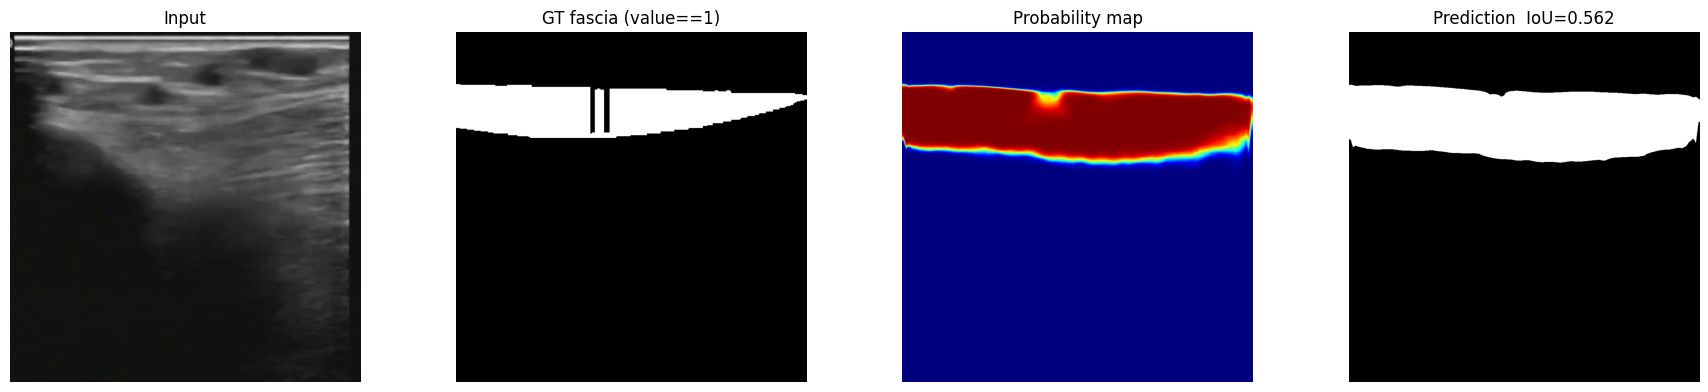

IoU = 0.5616  |  idx=0  |  file=000000_Ultrasound_PeripheralVascular.png


In [ ]:
import matplotlib.pyplot as plt

idx = 0   # change to look at different examples

ann     = test_anns[idx]
pil_img = Image.open(TEST_IMG_DIR  / ann['file_name']).convert('RGB')
H, W    = pil_img.size[1], pil_img.size[0]
gt_bin  = (np.array(Image.open(TEST_MASK_DIR / ann['mask_file']).convert('L')) == 1).astype(np.uint8)

outputs, _ = infer_grounding(pil_img)
prob       = grounding_to_prob(outputs, H, W)
pred_bin   = (prob > 0.5).astype(np.uint8)

inter = int((pred_bin & gt_bin).sum())
union = int((pred_bin | gt_bin).sum())
iou   = inter / (union + 1e-6)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(pil_img);                              axes[0].set_title('Input')
axes[1].imshow(gt_bin,   cmap='gray');                axes[1].set_title('GT fascia (value==1)')
axes[2].imshow(prob,     cmap='jet', vmin=0, vmax=1); axes[2].set_title('Probability map')
axes[3].imshow(pred_bin, cmap='gray');                axes[3].set_title(f'Prediction  IoU={iou:.3f}')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
print(f'IoU = {iou:.4f}  |  idx={idx}  |  file={ann["file_name"]}')